In [1]:
%load_ext autoreload
%autoreload 2

import sys

sys.path.append('..')

import torch
from torch.distributions import Normal, MultivariateNormal

import matplotlib.pyplot as plt

from typing import Callable


## Old

In [2]:
def projection_onto_a_line(theta: torch.Tensor) -> Callable[[torch.Tensor, torch.Tensor], torch.Tensor]:
    """
    Creates a function that projects points onto a line.
    Args:
        theta: Angle tensor of any shape
    Returns:
        Function that takes x,y coordinates and projects them onto the line
    """

    def project(x: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
        return x * torch.cos(theta) + y * torch.sin(theta)

    return project


def chebyshev_2(t: torch.Tensor) -> torch.Tensor:
    """
    Chebyshev polynomial of the 2nd degree.

    Args:
        t: Input tensor of any shape

    Returns:
        Tensor of same shape as input with Chebyshev polynomial applied
    """
    return 2 * t.pow(2) - 1


def klein_filter(theta_1: torch.Tensor, theta_2: torch.Tensor) -> Callable[[torch.Tensor, torch.Tensor], torch.Tensor]:
    """
    Klein filter for given angles theta_1 and theta_2.

    Args:
        theta_1: First angle tensor
        theta_2: Second angle tensor

    Returns:
        Function that takes x,y coordinates and applies the Klein filter
    """
    t = projection_onto_a_line(theta_1)

    def filter_fn(x: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
        return torch.sin(theta_2) * t(x, y) + torch.cos(theta_2) * chebyshev_2(t(x,y))

    return filter_fn


def generate_klein_filter_matrix(
    theta_1: torch.Tensor, theta_2: torch.Tensor, size: int = 3, midpoint: bool = False, device: torch.device = None
) -> torch.Tensor:
    """
    Generate a Klein filter matrix of given size for specified angles.

    Args:
        theta_1: First angle tensor
        theta_2: Second angle tensor
        size: Size of the matrix
        midpoint: If True, use midpoints for the grid; otherwise, use edges
        device: PyTorch device to place tensors on. If None, uses theta_1's device

    Returns:
        Tensor of shape [size, size] containing the Klein filter values
    """
    if device is None:
        device = theta_1.device

    f = klein_filter(theta_1, theta_2)

    if midpoint:
        coords = torch.linspace(-1 + 1 / size, 1 - 1 / size, size, device=device)
    else:
        coords = torch.linspace(-1, 1, size, device=device)

    X, Y = torch.meshgrid(coords, coords, indexing="ij")
    return f(X, Y)


def generate_klein_filter_matrix_via_integration(
    theta_1: torch.Tensor, theta_2: torch.Tensor, size: int = 3, num_samples: int = 100, device: torch.device = None
) -> torch.Tensor:
    """
    Generate a Klein filter matrix using Monte Carlo integration.

    Args:
        theta_1: First angle tensor
        theta_2: Second angle tensor
        size: Size of the matrix
        num_samples: Number of random samples per cell for integration
        device: PyTorch device to place tensors on. If None, uses theta_1's device

    Returns:
        Tensor of shape [size, size] containing the integrated Klein filter values
    """
    if device is None:
        device = theta_1.device

    f = klein_filter(theta_1, theta_2)
    result = torch.zeros(size, size, device=device)

    for x in range(size):
        for y in range(size):
            xmin = -1.0 + ((2 * x) / (2 * size))
            xmax = -1.0 + ((2 * (x + 1.0)) / (2 * size))
            ymin = -1.0 + ((2 * y) / (2 * size))
            ymax = -1.0 + ((2 * (y + 1.0)) / (2 * size))

            # Generate random samples in the cell
            x_samples = torch.rand(num_samples, device=device) * (xmax - xmin) + xmin
            y_samples = torch.rand(num_samples, device=device) * (ymax - ymin) + ymin

            # Compute filter values and average
            filter_values = f(x_samples, y_samples)
            result[y, x] = filter_values.mean() * (xmax - xmin) * (ymax - ymin)

    return result


In [3]:
normal_dist = Normal(torch.tensor(0.0), torch.tensor(1.0))

In [4]:
theta_1, theta_2 = normal_dist.sample(sample_shape=torch.Size([1, 2])).chunk(2, dim=-1)
theta_1, theta_2 = theta_1 % torch.pi, theta_2 % 2 * torch.pi
print(theta_1, theta_2)

tensor([[0.3836]]) tensor([[3.4492]])


In [5]:
generate_klein_filter_matrix(theta_1, theta_2, size=3, midpoint=True, device=torch.device('cpu'))

tensor([[-0.2194,  0.4117,  0.8055],
        [ 0.9100,  0.9531,  0.7589],
        [ 0.5822,  0.0373, -0.7448]])

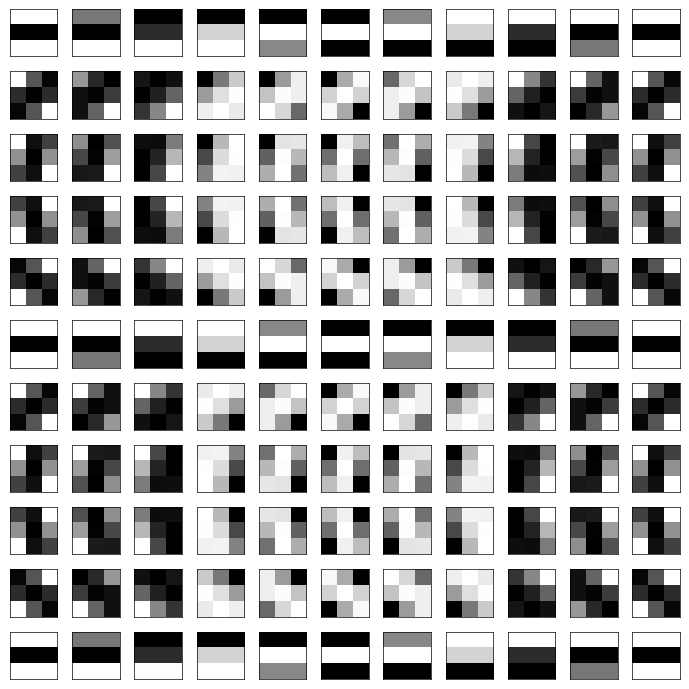

In [6]:
n = 10

fig, axes = plt.subplots(n+1, n+1, figsize=(7, 7))
for i in range(0, n+1):
    for j in range(0, n+1):
        theta_1 = torch.Tensor([2 * torch.pi * i / n])
        theta_2 = torch.Tensor([2 * torch.pi * j / n])
        filter_img = generate_klein_filter_matrix(theta_1, theta_2, size=3, midpoint=False)
        axes[i, j].imshow(filter_img.cpu().numpy(), cmap='gray', extent=[-1, 1, -1, 1])
        for spine in axes[i, j].spines.values():
            spine.set_edgecolor('black')
            spine.set_linewidth(0.5)
        axes[i, j].set_xticks([])
        axes[i, j].set_yticks([])

plt.tight_layout()
plt.show()


## Testing my code

In [89]:
from src.klein_normal import KleinNormal
from src.utils import project_to_klein, project_to_torus, preimage_of_klein, preimage_of_torus_grid

In [132]:
normal_on_klein = KleinNormal(0, 1)

loc must be a tensor of shape [2].
Creating a shape [2] tensor (0.00,0.00).
loc = tensor([0., 0.])
scale must be a tensor of shape [2].
Creating a shape [2] tensor (1.00,1.00).
scale = tensor([[1., 0.],
        [0., 1.]])
torch.Size([2]) torch.Size([2, 2])


In [91]:
norm = MultivariateNormal(torch.Tensor([0,0]), covariance_matrix=torch.eye(2))
samples = norm.rsample(torch.Size([1000]))

print(samples.shape)

torch.exp(norm.log_prob(samples)).sum()

torch.Size([1000, 2])


tensor(79.0322)

In [92]:
# For 1D case - integrate density over domain
n_points = 1000
x_range = torch.linspace(-4, 4, n_points)
y_range = torch.linspace(-4, 4, n_points)
X, Y = torch.meshgrid(x_range, y_range, indexing='ij')
grid_points = torch.stack([X.flatten(), Y.flatten()], dim=1)  # (10000, 2)

log_probs = norm.log_prob(grid_points)  # (10000,)
densities = torch.exp(log_probs)

# Reshape back to grid and integrate using trapezoidal rule
densities_grid = densities.reshape(n_points, n_points)
dx = x_range[1] - x_range[0]
dy = y_range[1] - y_range[0]

# 2D trapezoidal integration
integral = torch.trapz(torch.trapz(densities_grid, dx=dy, dim=1), dx=dx, dim=0)

print(f"Numerical integral: {integral.item():.6f}")
print(f"Should be close to 1.0")

# Alternative: simple Riemann sum
riemann_integral = torch.sum(densities) * dx * dy
print(f"Riemann sum: {riemann_integral.item():.6f}")

Numerical integral: 0.999872
Should be close to 1.0
Riemann sum: 0.999874


In [133]:
sampled = normal_on_klein.rsample(torch.Size([10]))
sampled.shape

torch.Size([10, 2])

In [134]:
normal_on_klein.log_prob(sampled)

Preimages of Klein: torch.Size([10, 2, 2]), Preimages of Torus: torch.Size([10, 18, 2])


tensor([-2.2314, -2.1515, -1.9502, -2.7081, -2.1687, -2.3719, -2.5988, -2.3467,
        -1.9128, -2.5556])

In [135]:
# For 1D case - integrate density over domain
n_points = 10 #
x_range = torch.linspace(0, torch.pi, n_points)
y_range = torch.linspace(0, 2 * torch.pi, n_points)
X, Y = torch.meshgrid(x_range, y_range, indexing='ij')
grid_points = torch.stack([X.flatten(), Y.flatten()], dim=1)  # (10000, 2)

print(grid_points.shape)

log_probs = normal_on_klein.log_prob(grid_points)  # (10000,)
print(log_probs.shape)
densities = torch.exp(log_probs)

# Reshape back to grid and integrate using trapezoidal rule
densities_grid = densities.reshape(n_points, n_points)
dx = x_range[1] - x_range[0]
dy = y_range[1] - y_range[0]

# 2D trapezoidal integration
integral = torch.trapz(torch.trapz(densities_grid, dx=dy, dim=1), dx=dx, dim=0)

print(f"Numerical integral: {integral.item():.6f}")
print(f"Should be close to 1.0")

# Alternative: simple Riemann sum
riemann_integral = torch.sum(densities) * dx * dy

#* Riemann sum -> 1 when n_points -> infty
print(f"Riemann sum: {riemann_integral.item():.6f}")

torch.Size([100, 2])
Preimages of Klein: torch.Size([100, 2, 2]), Preimages of Torus: torch.Size([100, 18, 2])
torch.Size([100])
Numerical integral: 1.000000
Should be close to 1.0
Riemann sum: 1.459117


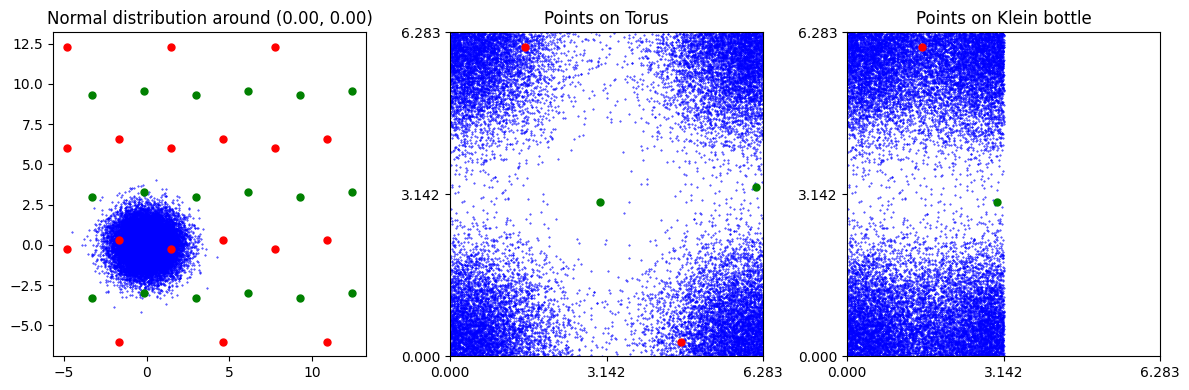

In [139]:
# Example usage

torch.random.manual_seed(28)

loc=torch.Tensor([0, 0])
scale = 1 #torch.Tensor([[1, 0], [0, 1]]) #* difference from numpy: in numpy cov is sigma^2, in pytorch it is sigma

points = torch.distributions.Normal(loc=loc, scale=scale).sample(sample_shape=torch.Size([20_000]))

klein_points = project_to_klein(points)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].plot(points[:,0], points[:,1], 'o', markersize=0.4, color='blue')
axes[0].set_title(f'Normal distribution around ({loc[0]:.2f}, {loc[1]:.2f})')


axes[1].plot(torch.remainder(points[:,0], 2 * torch.pi), torch.remainder(points[:,1], 2 * torch.pi), 'o', markersize=0.4, color='blue')
axes[1].set_title('Points on Torus')
axes[1].set_xlim(0, 2 * torch.pi)
axes[1].set_ylim(0, 2 * torch.pi)
axes[1].axes.get_xaxis().set_ticks([0, torch.pi, 2 * torch.pi])
axes[1].axes.get_yaxis().set_ticks([0, torch.pi, 2 * torch.pi])

axes[2].plot(klein_points[:,0], klein_points[:,1], 'o', markersize=0.4, color='blue')
axes[2].set_title('Points on Klein bottle')
axes[2].set_xlim(0, 2 * torch.pi)
axes[2].set_ylim(0, 2 * torch.pi)
axes[2].axes.get_xaxis().set_ticks([0, torch.pi, 2 * torch.pi])
axes[2].axes.get_yaxis().set_ticks([0, torch.pi, 2 * torch.pi])

# Choose a single point (e.g. the first one) to highlight
p_klein = torch.Tensor([[1.5, 6], [3,3]]) #sampled #torch.Tensor([3, 3]) #klein_points[28]#np.array([1.5, 6])
p_torus = preimage_of_klein(p_klein)
p_plane = preimage_of_torus_grid(p_torus) #preimage_of_torus_grid(p_torus) #preimage_of_torus_recursive(p_torus)

# Plot in red on each subplot
axes[0].plot(p_plane[0,:,0], p_plane[0,:,1], 'ro', markersize=5)
axes[0].plot(p_plane[1,:,0], p_plane[1,:,1], 'go', markersize=5)

axes[1].plot(p_torus[0,:,0], p_torus[0,:,1], 'ro', markersize=5)
axes[1].plot(p_torus[1,:,0], p_torus[1,:,1], 'go', markersize=5)

axes[2].plot(p_klein[0,0], p_klein[0,1], 'ro', markersize=5)
axes[2].plot(p_klein[1,0], p_klein[1,1], 'go', markersize=5)

plt.tight_layout()
plt.show()

Preimage of point tensor([1.5000, 6.0000]) on Torus:
 tensor([[[1.5000, 6.0000],
         [4.6416, 0.2832]]])
Preimage shape: torch.Size([1, 18, 2])
Preimage of point tensor([[[1.5000, 6.0000],
         [4.6416, 0.2832]]]) on Plane:
 tensor([[[-4.7832, -0.2832],
         [-1.6416, -6.0000],
         [-4.7832,  6.0000],
         [-1.6416,  0.2832],
         [-4.7832, 12.2832],
         [-1.6416,  6.5664],
         [ 1.5000, -0.2832],
         [ 4.6416, -6.0000],
         [ 1.5000,  6.0000],
         [ 4.6416,  0.2832],
         [ 1.5000, 12.2832],
         [ 4.6416,  6.5664],
         [ 7.7832, -0.2832],
         [10.9248, -6.0000],
         [ 7.7832,  6.0000],
         [10.9248,  0.2832],
         [ 7.7832, 12.2832],
         [10.9248,  6.5664]]])


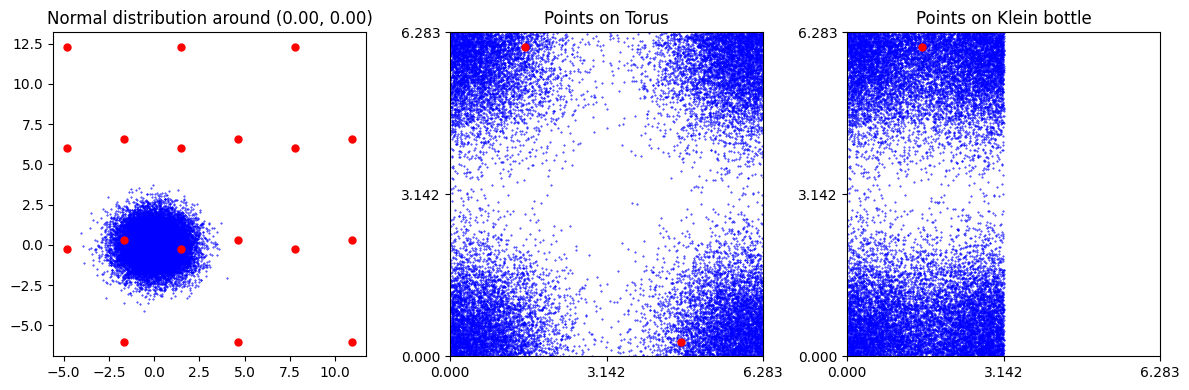

In [ ]:
import torch #! DEBUG

def project_klein(points: torch.Tensor) -> torch.Tensor:
    print(points.shape)
    theta1, theta2 = points[:,0], points[:,1]
    u = torch.remainder(theta1, 2 * torch.pi)
    v = torch.remainder(theta2, 2 * torch.pi)

    u_mask = (u >= torch.pi)
    u[u_mask] = u[u_mask] - torch.pi
    v[u_mask] = torch.remainder(-v[u_mask], 2 * torch.pi)

    return torch.stack([u, v], dim=-1)

def preimage_of_klein(points: torch.Tensor) -> torch.Tensor:
    """
    Preimage of points on Klein bottle to points on Torus.
    Args:
        points: Tensor of shape (N, 2) representing points on the Klein bottle
    Returns:
        Tensor of shape (N, 2, 2) representing 2 preimages on the Torus, where 
            - the first dimension is the batch size,
            - the second dimension is the preimage index (0 or 1) corresponding to the two possible preimages,
            - the third dimension contains the x and y coordinates.
    """
    xs, ys = points[:, 0], points[:, 1]
    xs_torus = torch.stack([xs, xs + torch.pi], dim=-1)
    ys_torus = torch.stack([ys, torch.remainder(-ys, 2 * torch.pi)], dim=-1) 
    #torch.remainder(torch.cat([ys, -ys]), 2 * torch.pi).reshape(1, -1)

    return torch.stack([xs_torus, ys_torus], dim=-1)

def preimage_of_torus_grid(points: torch.Tensor, grid_size: int = 1) -> torch.Tensor:
    xs, ys = points[..., 0], points[..., 1]
    shifts = range(-grid_size, grid_size + 1)
    all_preimages = []

    for i in shifts:
        for j in shifts:
            x_shifted = xs + 2 * torch.pi * i
            y_shifted = ys + 2 * torch.pi * j
            all_preimages.append(torch.stack([x_shifted, y_shifted], dim=-1))

    return torch.cat(all_preimages, dim=1) # Shape: (N, 2 * (2 * grid_size + 1), 2)


loc=torch.Tensor([0, 0])
scale = 1 #torch.Tensor([[1, 0], [0, 1]]) #* difference from numpy: in numpy cov is sigma^2, in pytorch it is sigma

points = torch.distributions.Normal(loc=loc, scale=scale).sample(sample_shape=torch.Size([20_000]))

klein_points = project_to_klein(points)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].plot(points[:,0], points[:,1], 'o', markersize=0.4, color='blue')
axes[0].set_title(f'Normal distribution around ({loc[0]:.2f}, {loc[1]:.2f})')


axes[1].plot(torch.remainder(points[:,0], 2 * torch.pi), torch.remainder(points[:,1], 2 * torch.pi), 'o', markersize=0.4, color='blue')
axes[1].set_title('Points on Torus')
axes[1].set_xlim(0, 2 * torch.pi)
axes[1].set_ylim(0, 2 * torch.pi)
axes[1].axes.get_xaxis().set_ticks([0, torch.pi, 2 * torch.pi])
axes[1].axes.get_yaxis().set_ticks([0, torch.pi, 2 * torch.pi])

axes[2].plot(klein_points[:,0], klein_points[:,1], 'o', markersize=0.4, color='blue')
axes[2].set_title('Points on Klein bottle')
axes[2].set_xlim(0, 2 * torch.pi)
axes[2].set_ylim(0, 2 * torch.pi)
axes[2].axes.get_xaxis().set_ticks([0, torch.pi, 2 * torch.pi])
axes[2].axes.get_yaxis().set_ticks([0, torch.pi, 2 * torch.pi])

# Choose a single point (e.g. the first one) to highlight
p_klein = torch.Tensor([1.5, 6]) #klein_points[28] #np.array([1.5, 6])
p_torus = preimage_of_klein(p_klein.reshape(1, -1))
print(f'Preimage of point {p_klein} on Torus:\n {p_torus}')
p_plane = preimage_of_torus_grid(p_torus) #preimage_of_torus_grid(p_torus) #preimage_of_torus_recursive(p_torus)
print(f'Preimage of point {p_torus} on Plane:\n {p_plane}')

# Plot in red on each subplot
axes[0].plot(p_plane[0,:,0], p_plane[0,:,1], 'ro', markersize=5)
axes[1].plot(p_torus[0,:,0], p_torus[0,:,1], 'ro', markersize=5)
#axes[1].plot(np.remainder(p_plane[0], 2 * np.pi), np.remainder(p_plane[1], 2 * np.pi), 'ko', markersize=5)
axes[2].plot(p_klein[0], p_klein[1], 'ro', markersize=5)

plt.tight_layout()
plt.show()